In [23]:
import pandas as pd
import numpy as np
import tkinter as tk
import matplotlib.pyplot as plt
import time

from pathlib import Path
from tkinter import filedialog
from scipy.stats import gaussian_kde
from sklearn.model_selection import KFold
from sklearn.neighbors import KernelDensity


In [24]:
def load_dataframe_from_path(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
        
    elif ext in [".otus", ".txt", ".meta", ".taxonomy"]:
        df = pd.read_csv(path, sep="\t")
        
    else:
        raise ValueError(
            f"Formato no soportado: {ext}. "
            "Usa archivos .csv, .otus, .txt, .meta o .taxonomy"
        )

    return df


def load_multiple_dataframes():
    root = tk.Tk()
    root.withdraw()  
    root.attributes("-topmost", True)  

    file_paths = filedialog.askopenfilenames(
        title="Selecciona uno o varios datasets",
        filetypes=[
            ("Archivos soportados", "*.csv *.otus *.txt *.meta *.taxonomy"),
            ("CSV", "*.csv"),
            ("OTUS", "*.otus"),
            ("TXT", "*.txt"),
            ("META", "*.meta"),
            ("TAXONOMY", "*.taxonomy"),
            ("Todos los archivos", "*.*")
        ]
    )

    if not file_paths:
        print("No se seleccionó ningún archivo.")
        return {}

    dataframes = {}

    for file_path in file_paths:
        path = Path(file_path)
        try:
            df = load_dataframe_from_path(path)
            dataframes[path.stem] = df
            print(f"Cargado: {path.name} -> shape {df.shape}")
        except Exception as e:
            print(f"Error al cargar {path.name}: {e}")

    return dataframes

In [25]:
dfs = load_multiple_dataframes()

if not dfs:
    print("No se cargó ningún archivo.")
else:
    for nombre, df in dfs.items():
        print(f"\nArchivo cargado: {nombre}")
        print(f"Shape del DataFrame: {df.shape}")
        print(f"Columnas: {df.columns.tolist()[:10]}{' ...' if len(df.columns) > 10 else ''}")

Cargado: otu_data_converted.csv -> shape (441, 4739)

Archivo cargado: otu_data_converted
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009'] ...


In [26]:
def get_otu_positive_values(dfs, data_df_name="otu_data_converted"):
    if data_df_name not in dfs:
        raise KeyError(f"No existe '{data_df_name}' en dfs. Disponibles: {list(dfs.keys())}")

    df = dfs[data_df_name].copy()
    values = df.select_dtypes(include=[np.number]).to_numpy(dtype=float).ravel()
    values = values[np.isfinite(values)]
    positives = values[values > 0]

    if positives.size == 0:
        raise ValueError(f"'{data_df_name}' no contiene valores numericos positivos.")

    return positives, df.shape


def suggest_grid_size(n_values):
    if n_values <= 250_000:
        return 1000
    if n_values <= 1_000_000:
        return 1500
    return 2000


def make_log_grid(values, grid_size, bandwidth):
    positives = np.asarray(values, dtype=float).ravel()
    positives = positives[np.isfinite(positives)]
    positives = positives[positives > 0]

    if positives.size == 0:
        raise ValueError("Se requiere al menos un valor positivo.")
    if bandwidth <= 0:
        raise ValueError("El bandwidth debe ser positivo.")

    lower = max(float(np.min(positives)) * 1e-3, 1e-12)
    upper = float(np.max(positives) + 8.0 * bandwidth)
    return np.logspace(np.log10(lower), np.log10(upper), int(grid_size))


In [27]:
def grid_estimation_from_loaded(
    dfs,
    data_df_name="otu_data_converted",
    bandwidth_for_grid=100.0,
    grid_size=1000,
    verbose=True
):
    values, data_shape = get_otu_positive_values(dfs, data_df_name=data_df_name)
    grid_suggestion = suggest_grid_size(len(values))
    x_grid = make_log_grid(values, grid_size, bandwidth_for_grid)

    data_summary = pd.DataFrame([{
        "filas": data_shape[0],
        "columnas": data_shape[1],
        "valores_positivos": len(values),
        "grid_sugerido": grid_suggestion,
        "grid_usado": grid_size,
    }])

    grid_summary = pd.DataFrame([{
        "grid_size": grid_size,
        "minimo_grid": float(x_grid.min()),
        "maximo_grid": float(x_grid.max()),
        "minimo_datos": float(values.min()),
        "maximo_datos": float(values.max()),
    }])

    if verbose:
        print(f"DataFrame analizado: {data_df_name}")
        print(f"Valores positivos: {len(values)}")
        print(f"Grid sugerido: {grid_suggestion}")
        print(f"Grid usado: {grid_size}")
        print("Valor para copiar:")
        print(f"grid_size = {grid_size}")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(values, bins=80, density=True, alpha=0.35, label="Valores positivos")
    ax.scatter(x_grid, np.zeros_like(x_grid), s=4, alpha=0.25, label="Grilla")
    ax.set_xscale("log")
    ax.set_xlabel("Valor OTU positivo")
    ax.set_ylabel("Densidad empirica")
    ax.set_title("Grilla logaritmica propuesta")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    result = {
        "values": values,
        "x_grid": x_grid,
        "data_summary": data_summary,
        "grid_summary": grid_summary,
    }

    return result


DataFrame analizado: otu_data_converted
Valores positivos: 105420
Grid sugerido: 1000
Grid usado: 1000
Valor para copiar:
grid_size = 1000


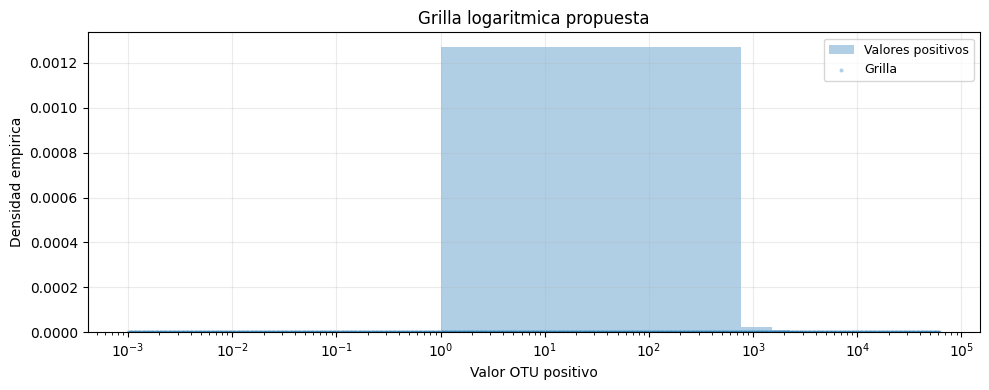

In [28]:
grid_outputs = grid_estimation_from_loaded(
    dfs=dfs,
    data_df_name="otu_data_converted",
    bandwidth_for_grid=100.0,
    grid_size=1000,
    verbose=True,
)
